In [1]:
import scanpy as sc
import numpy as np
import anndata as ad
from datasets import load_from_disk

# calculate_perturbation_effect(embeddings, gp_list, meta_cols):

In [2]:
import pandas as pd

In [3]:
import seaborn as sns

In [4]:
import matplotlib.pyplot as plt
plt.rcParams.update(plt.rcParamsDefault)


In [5]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42


In [6]:
def get_path(training_split, run, output_name = 'global'):
    base_path = 'tripso_reproducibility/04.5_HSC_post_qc'
    return f'{base_path}/{run}_by_study/output_{output_name}/ablation/with_gp_ablation/{training_split}_set.h5ad'

In [7]:
train1 = sc.read_h5ad(get_path('train', 'run_1'))

val1 = sc.read_h5ad(get_path('val', 'run_1'))

test1 = sc.read_h5ad(get_path('test', 'run_1'))

pert_data1 = ad.concat([train1, val1, test1])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
train2 = sc.read_h5ad(get_path('train', 'run_2'))

val2 = sc.read_h5ad(get_path('val', 'run_2'))

test2 = sc.read_h5ad(get_path('test', 'run_2'))

pert_data2 = ad.concat([train2, val2, test2])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [9]:
train3 = sc.read_h5ad(get_path('train', 'run_3'))

val3 = sc.read_h5ad(get_path('val', 'run_3'))

test3 = sc.read_h5ad(get_path('test', 'run_3'))

pert_data3 = ad.concat([train3, val3, test3])

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [10]:
pert_data = sc.AnnData(
    X = (pert_data1.X + pert_data2.X + pert_data3.X)/3,
    obs = pert_data1.obs,
    var = pert_data1.var
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [11]:
pert_data = pert_data[pert_data.obs['study'].str.contains('Isobe')]

In [12]:
pert_data.obs['tissue'] = pert_data.obs['tissue'].cat.reorder_categories(
    ['YS', 'FL', 'FBM', 'CB', 'PBM', 'ABM_29-50y', 'ABM_+60y']
    )

/tmp/ipykernel_1770407/995721982.py:1: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  pert_data.obs['tissue'] = pert_data.obs['tissue'].cat.reorder_categories(
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [13]:
def add_gp_score_to_obs(adata_expr, adata_pert, gp):
    gp_scores = adata_pert[:, adata_pert.var.index == gp].X.flatten()
    adata_pert.obs[f'{gp}_importance_score'] = list(gp_scores)
        
    score_df = adata_pert.obs[['idx', f'{gp}_importance_score']]
            
    adata_expr.obs = adata_expr.obs.join(score_df.set_index('idx'))
    
    return adata_expr
    

In [14]:

adata = pert_data[pert_data.obs['study'].isin(['Isobe_MNC', 'Isobe_CD34'])]

# Filter erythroid cells
ery_ct = [
    # MNC
    # '1_HSC_MPP',
    '2_MEMP', '4_BFU-E/CFU-E', '5_Early_erythroblast', '6_Mid_erythroblast', 
    '7_Late_erythroblast', '8_HBE+_embryonic_erythrocyte',
    
    # CD34
    '1_LT-HSC', '2_ST-HSC', '3_MPP', '4_MEMP', 
    '6_Early_Ery', '7_Late_Ery', 
         ]


adata = adata[adata.obs['cell_type'].isin(ery_ct)]


pd.crosstab(pert_data.obs['cell_type'], pert_data.obs['study'])

# Update CD34 labels to most up to date version from Tomo
adata.obs['cell_type'] = adata.obs['cell_type'].replace(
    {
        '6_Early_Ery' : '6_BFU-E/CFU-E',
        '7_Late_Ery' : '7_Early_erythroblast',        
    }
)

adata.obs['cell_label'] = adata.obs['cell_type'].str.replace(r'^\d+_', '', regex=True)


/tmp/ipykernel_1770407/3452655060.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['cell_type'] = adata.obs['cell_type'].replace(
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [15]:
adata.obs['cell_label'] = pd.Categorical(
    adata.obs['cell_label'], 
    categories = ['LT-HSC', 'ST-HSC', 
                  # 'HSC_MPP',
                   'MPP', 'MEMP', 
                  'BFU-E/CFU-E',
                   'Early_erythroblast',
                  'Mid_erythroblast',
                  'Late_erythroblast', 
       'HBE+_embryonic_erythrocyte'],
    ordered = True
)
    

In [16]:
def categorical_heatmap(
    adata,
    var_names,
    groupby,
    layer="Ms",
    color_map="viridis",
    palette="viridis",
    n_convolve=20,
    min_max_scale=None,
    standard_scale=None,
    colorbar=None,
    context=None,
    font_scale=None,
    figsize=(10, 4),
    show=None,
    save=None,
    **kwargs,
):
    import seaborn as sns
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    from scipy.sparse import issparse

    # Filter valid genes
    var_names = [g for g in var_names if g in adata.var_names]
    if not var_names:
        raise ValueError("No valid var_names found in adata.")

    group_vals = adata.obs[groupby].astype("category")
    group_categories = group_vals.cat.categories

    # Extract expression data
    X = (
        adata[:, var_names].layers[layer]
        if layer in adata.layers
        else adata[:, var_names].X
    )
    if issparse(X):
        X = X.toarray()

    df = pd.DataFrame(X, columns=var_names)
    df["group"] = group_vals.values
    
    sorted_idx = []
    for group in group_categories:
        sub_df = df[df["group"] == group].drop("group", axis=1).copy()
        if n_convolve:
            weights = np.ones(n_convolve) / n_convolve
            for gene in var_names:
                try:
                    sub_df[gene] = np.convolve(sub_df[gene].values, weights, mode="same")
                except Exception as e:
                    print(f"Skipping gene {gene} due to error: {e}")
        sub_idx = sub_df.index[np.argsort(sub_df[var_names[0]].values)]
        sorted_idx.extend(sub_idx)

    df_sorted = df.loc[sorted_idx]
    df_sorted_expr = df_sorted.drop("group", axis=1)

    if min_max_scale == 0:
        df_sorted_expr = (df_sorted_expr.T - df_sorted_expr.T.min()) / (df_sorted_expr.T.max() - df_sorted_expr.T.min())
        df_sorted_expr = df_sorted_expr.T

    elif min_max_scale == 1:
        df_sorted_expr = (df_sorted_expr - df_sorted_expr.min()) / (df_sorted_expr.max() - df_sorted_expr.min())

    df_sorted = pd.concat([df_sorted_expr, df_sorted["group"]], axis=1)

    numeric_columns = df_sorted.select_dtypes(include=[np.number]).columns
    if df_sorted[numeric_columns].isna().any().any():
        print("Warning: NaN values found, replacing with 0.")
        df_sorted[numeric_columns] = df_sorted[numeric_columns].fillna(0)
    if np.isinf(df_sorted[numeric_columns].values).any():
        print("Warning: Inf values found, replacing with 0.")
        df_sorted[numeric_columns] = df_sorted[numeric_columns].replace([np.inf, -np.inf], 0)

    heat_data = df_sorted.drop("group", axis=1).T.values.astype(float)

    args = {}
    if font_scale:
        args = {"font_scale": font_scale}
        context = context or "notebook"

    with sns.plotting_context(context=context, **args):
        fig, ax = plt.subplots(figsize=figsize)

        cax = ax.imshow(heat_data, cmap=color_map, aspect='auto', interpolation='nearest')
        if colorbar:
            fig.colorbar(cax, ax=ax)

        current_pos = 0
        for i in range(len(df_sorted) - 1):
            if df_sorted.iloc[i]["group"] != df_sorted.iloc[i + 1]["group"]:
                ax.axvline(x=current_pos + 1, color='black', lw=1)
            current_pos += 1

        current_pos = 0
        for group in group_categories:
            group_cells = df[df["group"] == group]
            group_len = len(group_cells)
            mid_pos = current_pos + group_len // 2
            ax.text(mid_pos, -0.75, group, ha='center', va='center', fontsize=10, color='black')
            current_pos += group_len

        ax.set_yticks(np.arange(len(var_names)))
        ax.set_yticklabels(var_names, fontsize=8)
        ax.set_xticks([])  # Remove bottom x-axis ticks
        ax.set_ylabel("Genes")
        ax.set_xlabel(groupby)
        plt.tight_layout()

    if save:
        plt.savefig(save)
    
    if show or show is None:
        plt.show()
    
    plt.close()


In [17]:
glm_results = pd.read_csv('tripso_reproducibility/04.5_HSC_post_qc/run_1_by_study/output_global/erythropoiesis/glm_results.csv')




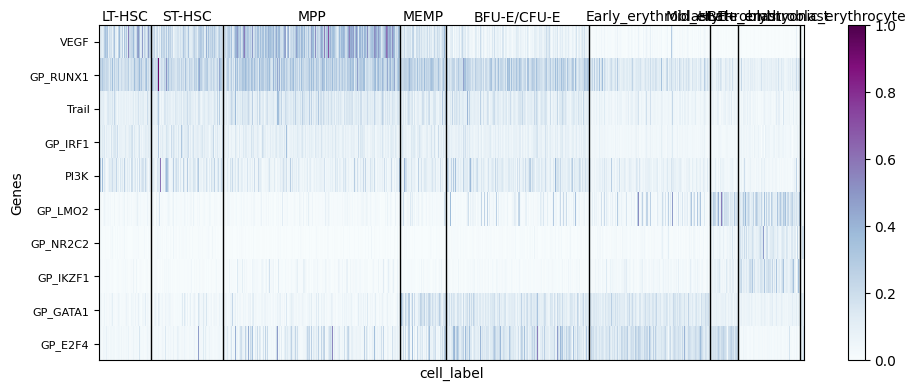

In [18]:
categorical_heatmap(
    adata,
    var_names = pd.concat([glm_results[glm_results['significant_fdr']].sort_values(by = 'coef')['gene'][:5],
               glm_results[glm_results['significant_fdr']].sort_values(by = 'coef')['gene'][-5:]]),
    groupby = 'cell_label',
    min_max_scale = 1,
    color_map = 'BuPu',
    n_convolve = 50,
    colorbar = True,
    save = 'ery_10gp_with_HBE.pdf'
)

In [19]:
adata.obs['cell_label'].value_counts()

cell_label
MPP                           21940
BFU-E/CFU-E                   17701
Early_erythroblast            15000
ST-HSC                         8867
Late_erythroblast              7624
LT-HSC                         6475
MEMP                           5635
Mid_erythroblast               3497
HBE+_embryonic_erythrocyte      513
Name: count, dtype: int64



 YS 


Skipping gene VEGF due to error: Length of values (30) does not match length of index (2)
Skipping gene GP_RUNX1 due to error: Length of values (30) does not match length of index (2)
Skipping gene GP_IRF1 due to error: Length of values (30) does not match length of index (2)
Skipping gene PI3K due to error: Length of values (30) does not match length of index (2)
Skipping gene GP_LMO2 due to error: Length of values (30) does not match length of index (2)
Skipping gene GP_NR2C2 due to error: Length of values (30) does not match length of index (2)
Skipping gene GP_IKZF1 due to error: Length of values (30) does not match length of index (2)
Skipping gene GP_GATA1 due to error: Length of values (30) does not match length of index (2)
Skipping gene VEGF due to error: Length of values (30) does not match length of index (1)
Skipping gene GP_RUNX1 due to error: Length of values (30) does not match length of index (1)
Skipping gene GP_IRF1 due to error: Length of values (30) does no

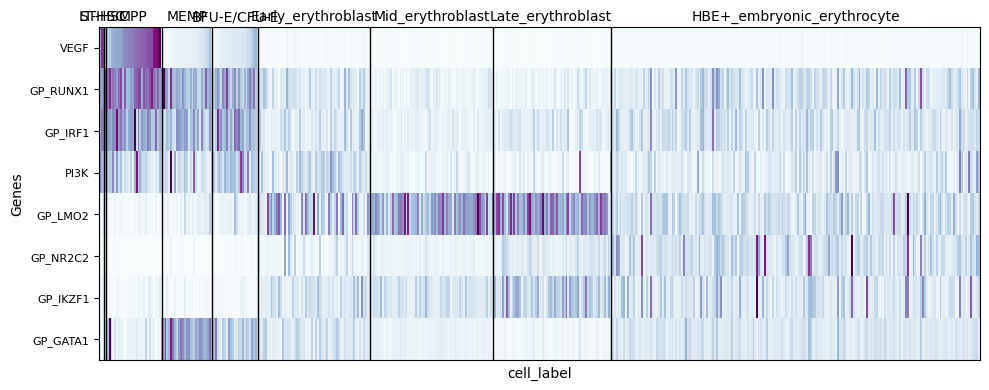



 FL 




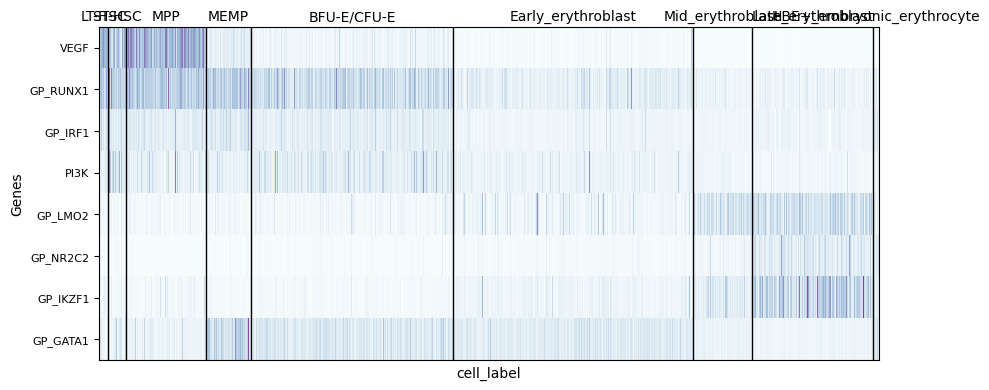



 FBM 




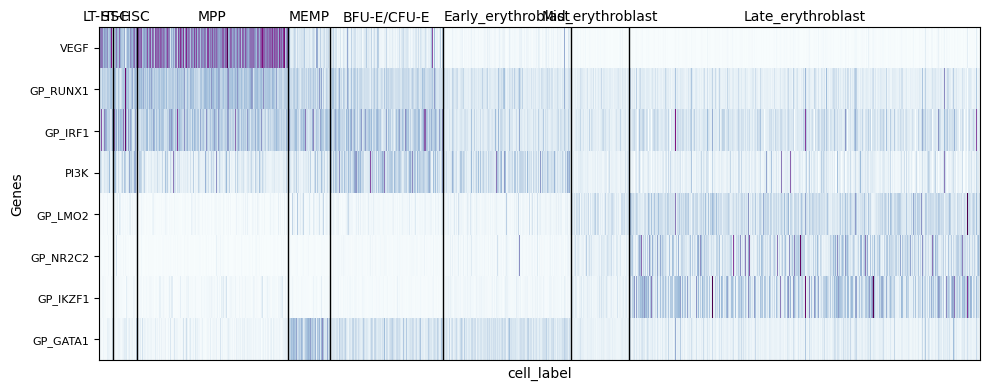



 CB 


Skipping gene VEGF due to error: Length of values (30) does not match length of index (9)
Skipping gene GP_RUNX1 due to error: Length of values (30) does not match length of index (9)
Skipping gene GP_IRF1 due to error: Length of values (30) does not match length of index (9)
Skipping gene PI3K due to error: Length of values (30) does not match length of index (9)
Skipping gene GP_LMO2 due to error: Length of values (30) does not match length of index (9)
Skipping gene GP_NR2C2 due to error: Length of values (30) does not match length of index (9)
Skipping gene GP_IKZF1 due to error: Length of values (30) does not match length of index (9)
Skipping gene GP_GATA1 due to error: Length of values (30) does not match length of index (9)
Skipping gene VEGF due to error: Length of values (30) does not match length of index (9)
Skipping gene GP_RUNX1 due to error: Length of values (30) does not match length of index (9)
Skipping gene GP_IRF1 due to error: Length of values (30) does no

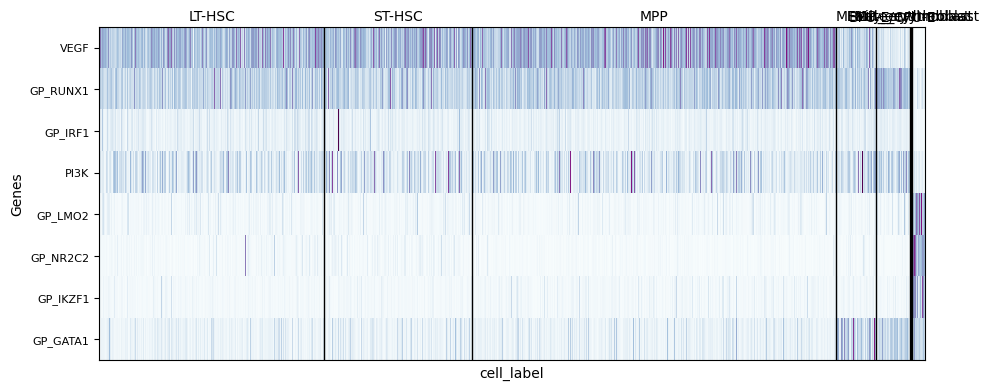



 PBM 




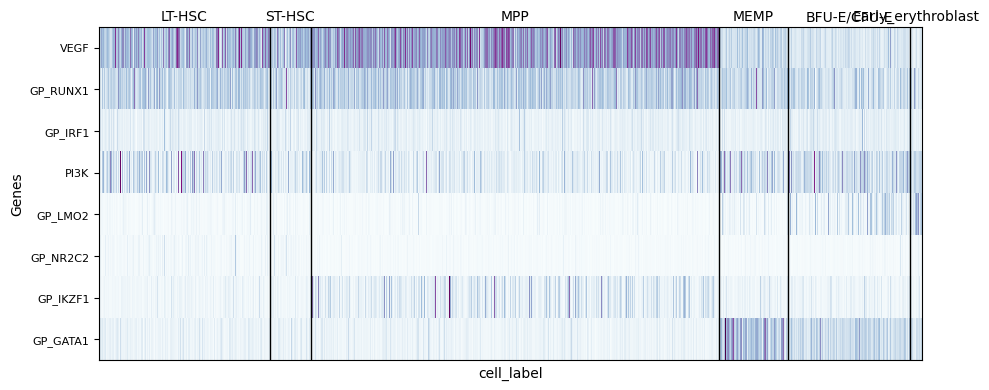



 ABM_29-50y 


Skipping gene VEGF due to error: Length of values (30) does not match length of index (21)
Skipping gene GP_RUNX1 due to error: Length of values (30) does not match length of index (21)
Skipping gene GP_IRF1 due to error: Length of values (30) does not match length of index (21)
Skipping gene PI3K due to error: Length of values (30) does not match length of index (21)
Skipping gene GP_LMO2 due to error: Length of values (30) does not match length of index (21)
Skipping gene GP_NR2C2 due to error: Length of values (30) does not match length of index (21)
Skipping gene GP_IKZF1 due to error: Length of values (30) does not match length of index (21)
Skipping gene GP_GATA1 due to error: Length of values (30) does not match length of index (21)


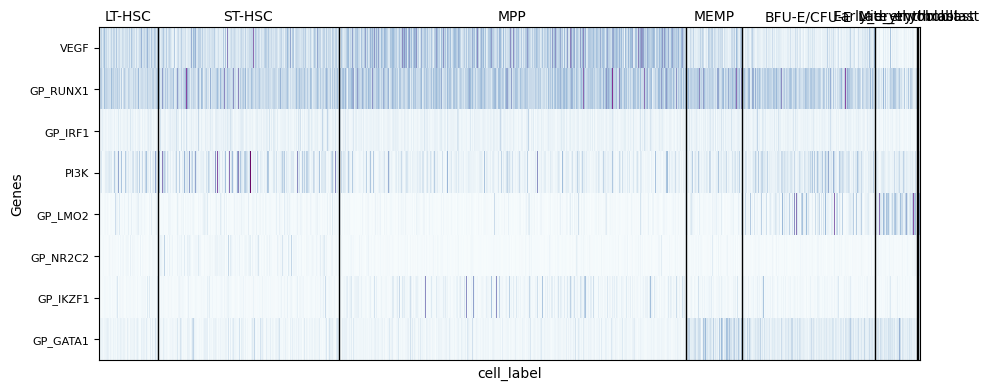



 ABM_+60y 




In [ ]:
for t in adata.obs['tissue'].cat.categories:
    print('\n\n', t, '\n\n')

    categorical_heatmap(
        adata[adata.obs['tissue'] == t],
        var_names = ['VEGF', 'GP_RUNX1', 'GP_IRF1', 'PI3K', 'GP_LMO2', 'GP_NR2C2', 
                     'GP_IKZF1', 'GP_GATA1', 
                     #'GP_E2F4'
                    ],
        groupby = 'cell_label',
        min_max_scale = 1,
        color_map = 'BuPu',
        n_convolve = 30,
    )